### Exercise for Graph 5
Your task:
1) Make the graph on the right! You need to implement an automatic Higher or Lower;(实现自动判断数字是高于还是低于当前数字的功能；)
3) set the bounds to between 1-20 the graph has to keep guessing (max number of guesses is 7 ) where if the guess is correct,then it stops,but if not we keep looping until we hit the max limit of 7;（将猜测范围设置为1-20 ，图需要不断猜测、最多猜测7次、否则 继续循环至7次上限；）
4) each time a number is guessed,the hint node should say higher or lower and the graph should accound for this information and guess the next guess accordingly;（图应该根据这个提示调整下一次的猜测；）
5) imput:{"player_name": student guesses:[]\attempts:0 lower-bound :1 upper_ bound :20} 
Hint :it will need to adjust its bounds after every guess based on the hint provided by the hint node;（每次猜测后都需要根据提示节点提供的提示调整其范围；）
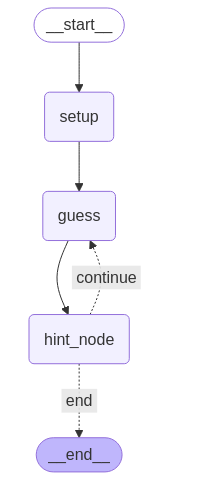

In [3]:
from typing import TypedDict,List
from langgraph.graph import StateGraph,END
import random

class GameState(TypedDict):
    player_name:str
    guesses:List[int] # 猜测
    attempts:int   #尝试的次数
    lower_bound:int  # 边界 下限
    upper_bound:int  
    target_number:int
    hint:str
    
     
   
    

In [4]:
def setup_node(state:GameState) -> GameState:
    """Initialize the game with a random target number """ # generate 生成
    state['player_name'] = f"Hi.there,{state['player_name']}welcome this game"
    state['target_number'] = random.randint(1,20)
    state['guesses'] = []
    state['attempts'] = 0
    state['hint'] = "Game started! Try to guess the number."
    state['lower_bound'] = 1
    state['upper_bound'] = 20
    print(f"{state['player_name']},The game has begun,I am thinking of a number between 1 and 20") 
    return state

def guess_node(state:GameState) ->GameState:
    """Generate a smarter guess based on previous hints"""
    possible_guesses = [i for i in range(state["lower_bound"], state["upper_bound"] + 1) if i not in state["guesses"]]
    if possible_guesses:
        guess = random.choice(possible_guesses)
    else:
        
        guess = random.randint(state["lower_bound"], state["upper_bound"])
    
    state["guesses"].append(guess)
    state["attempts"] += 1
    print(f"Attempt {state['attempts']}: Guessing {guess} (Current range: {state['lower_bound']}-{state['upper_bound']})")
    return state
 
def hint_node(state: GameState) -> GameState:
    """Here we provide a hint based on the last guess and update the bounds"""
    latest_guess = state["guesses"][-1]
    target = state["target_number"]
    
    if latest_guess < target:
        state["hint"] = f"The number {latest_guess} is too low. Try higher!"
        
        state["lower_bound"] = max(state["lower_bound"], latest_guess + 1)
        print(f"Hint: {state['hint']}")
        
    elif latest_guess > target:
        state["hint"] = f"The number {latest_guess} is too high. Try lower!"
      
        state["upper_bound"] = min(state["upper_bound"], latest_guess - 1)
        print(f"Hint: {state['hint']}")
    else:
        state["hint"] = f"Correct! You found the number {target} in {state['attempts']} attempts."
        print(f"Success! {state['hint']}")
    
    return state

def should_continue(state: GameState) -> str:
    """Determine if we should continue guessing or end the game"""
    
    # There are 2 end conditions - either 7 is reached or the correct number is guessed
    
    latest_guess = state["guesses"][-1]
    if latest_guess == state["target_number"]:
        print(f"GAME OVER: Number found!")
        return "end"
    elif state["attempts"] >= 7:
        print(f"GAME OVER: Maximum attempts reached! The number was {state['target_number']}")
        return "end"
    else:
        print(f"CONTINUING: {state['attempts']}/7 attempts used")
        return "continue"



In [5]:
graph = StateGraph(GgentState)
graph.add_node("setup",setup_node)
graph.add_node("guess", guess_node)
graph.add_node("hint_node", hint_node)  


graph.add_edge("setup", "guess")
graph.add_edge("guess", "hint_node")  


graph.add_conditional_edges(
    "hint_node", 
    should_continue,
    {
        "continue": "guess",
        "end": END
    }
)

graph.set_entry_point("setup")
app = graph.compile()

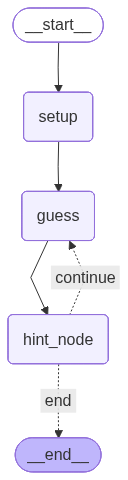

In [6]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))


In [7]:
result = app.invoke({"player_name": "Student", "guesses": [], "attempts": 0, "lower_bound": 1, "upper_bound": 20})

Hi.there,Studentwelcome this game,The game has begun,I am thinking of a number between 1 and 20
Attempt 1: Guessing 6 (Current range: 1-20)
Hint: The number 6 is too high. Try lower!
CONTINUING: 1/7 attempts used
Attempt 2: Guessing 4 (Current range: 1-5)
Hint: The number 4 is too low. Try higher!
CONTINUING: 2/7 attempts used
Attempt 3: Guessing 5 (Current range: 5-5)
Success! Correct! You found the number 5 in 3 attempts.
GAME OVER: Number found!
